# Демонстрация работы Lensless Computational Imaging

Этот ноутбук демонстрирует основные этапы реконструкции изображений, полученных при помощи безлинзовых камер, используя обученные модели.

Список доступных моделей:
- ADMM Unrolled`(admm_unrolled)`
- ADMM Pre-denoiser`(pre)`
- ADMM Post-denoiser`(post)`
- ADMM Pre- and Post-denoiser`(pre-post)` - по умолчанию

Если вы хотите использовать веса конкретной модели - измените поле `label` в разделе `Установка весов модели` в клетке с инициализацией `MODEL_GDRIVE_ID`.

**Как пользоваться:**

0. При желании выбрать `label` нужной вам модели.
1. Запусти все ячейки по порядку (Runtime $\rightarrow$ Run all).
2. После прогона в предпоследней секции появится визуализация результатов реконструкции изображений

## 1. Клонирование репозитория и установка зависимостей

In [1]:
# Клонирование репозитория
!git clone -b lensless-base https://github.com/DommeUse/Lensless-Computational-Imaging.git
%cd Lensless-Computational-Imaging

# Установка виртуального окружения для корректной установки зависимостей
!python -m pip install virtualenv
!python -m virtualenv /content/lensless_env

# Установка зависимостей и библиотеки gdown для работы с Google Drive
!/content/lensless_env/bin/pip install -r requirements.txt
!/content/lensless_env/bin/pip install -q gdown

Cloning into 'Lensless-Computational-Imaging'...
remote: Enumerating objects: 727, done.
remote: Counting objects: 100% (307/307), done.
remote: Compressing objects: 100% (231/231), done.
remote: Total 727 (delta 153), reused 173 (delta 72), pack-reused 420 (from 1)
Receiving objects: 100% (727/727), 1.70 MiB | 25.16 MiB/s, done.
Resolving deltas: 100% (327/327), done.
/content/Lensless-Computational-Imaging
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 120.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 470.6/470.6 kB 44.5 MB/s eta 0:00:00
created virtual environment CPython3.12.13.final.0-64-x86_64 in 499ms
  creator CPython3Posix(dest=/content/lensless_env, clear=False, no_vcs_ignore=False, global=False)
  seeder FromAppData(download=False, pip=bundle, via=copy, app_data_dir=/root/.cache/virtualenv)
    added seed packages: pip==26.1.2
  activators BashActivator,CShellActivator,FishActivator,NushellActivator,PowerShellActivator,PythonActivator,XonshActivator


## 2. Установка весов модели

In [2]:
from model_ids import MODEL_IDS

label = "pre-post" # выберите модель, которую хотите протестировать
MODEL_GDRIVE_ID, MODEL_CONFIG = MODEL_IDS[label]

Финальные веса модели хранятся на Google Drive. Утилита gdown скачивает их по публичной ссылке.

In [3]:
import os, gdown

CHECKPOINT_DIR = "checkpoints" # выберите название директории, куда загружать чекпоинты
CHECKPOINT_NAME = "model_best" # выберите имя загружаемого чекпоинта

os.makedirs(CHECKPOINT_DIR, exist_ok = True)
CHECKPOINT_PATH = f'{CHECKPOINT_DIR}/{CHECKPOINT_NAME}.pth'

gdown.download(id = MODEL_GDRIVE_ID, output = CHECKPOINT_PATH, quiet = False)

Downloading...
From (original): https://drive.google.com/uc?id=1cz_dO90ohu0v5xpdIhR-6FKEKK_Rr8_5
From (redirected): https://drive.google.com/uc?id=1cz_dO90ohu0v5xpdIhR-6FKEKK_Rr8_5&confirm=t&uuid=f4d45aba-b4b1-4ee5-b7f2-a4ad547af4f3
To: /content/Lensless-Computational-Imaging/checkpoints/model_best.pth
100%|██████████| 111M/111M [00:02<00:00, 46.1MB/s] 


'checkpoints/model_best.pth'

## 3. Загрузка датасета и запуск инференса

Вставьте ниже ссылку Google Drive на архив `.zip`.

Ячейка скачает архив, распакует его, найдёт корневую папку датасета (ту, где лежит `lensless/`), запустит `inference.py` и сохранит восстановленные изображения в формате `\<id\>.png` в папку `reconstructions/` (директория по умолчанию).

In [4]:
import gdown, zipfile, os, glob

DATASET_URL = "https://drive.google.com/file/d/1f32ASX1fUuC3hjaxFLYmzJRNLISqEPss/view?usp=sharing"   # Вставьте сюда свою ссылку на .zip на Google Drive
assert DATASET_URL, "Вставьте ссылку на Google Drive"

gdown.download(url = DATASET_URL, output = "data.zip", quiet = False, fuzzy = True)

with zipfile.ZipFile("data.zip") as z:
    z.extractall("data")

# Поиск директории, которая содержит 'lensless'
roots = [os.path.dirname(p) for p in glob.glob("data/**/lensless", recursive = True)]
DATA_DIR = roots[0] if roots else "data"
SAVE_DIR = "reconstructions"   # Директория с реконструкциями по умолчанию

print("dataset root :", DATA_DIR)
print("has ground truth (lensed/):", os.path.isdir(os.path.join(DATA_DIR, "lensed")))

Downloading...
From: https://drive.google.com/uc?id=1f32ASX1fUuC3hjaxFLYmzJRNLISqEPss
To: /content/Lensless-Computational-Imaging/data.zip
100%|██████████| 1.35M/1.35M [00:00<00:00, 93.4MB/s]

dataset root : data/demo_dataset
has ground truth (lensed/): True


In [5]:
import os
os.environ["MPLBACKEND"] = "Agg"

In [6]:
# Прогон датасета через модель и сохранение реконструкций
!/content/lensless_env/bin/python inference.py --config-name=inference \
    model={MODEL_CONFIG} \
    from_pretrained={CHECKPOINT_PATH} \
    datasets.data_dir="{DATA_DIR}" \
    +save_dir={SAVE_DIR}

Loaded weights from checkpoints/model_best.pth
Saved 3 reconstructions to /content/Lensless-Computational-Imaging/reconstructions


## 4. Визуализация нескольких примеров

Для каждого примера показываются:

Исходное изображение (если есть `lensed`) vs Безлинзовое изображение vs Восстановленное изображение

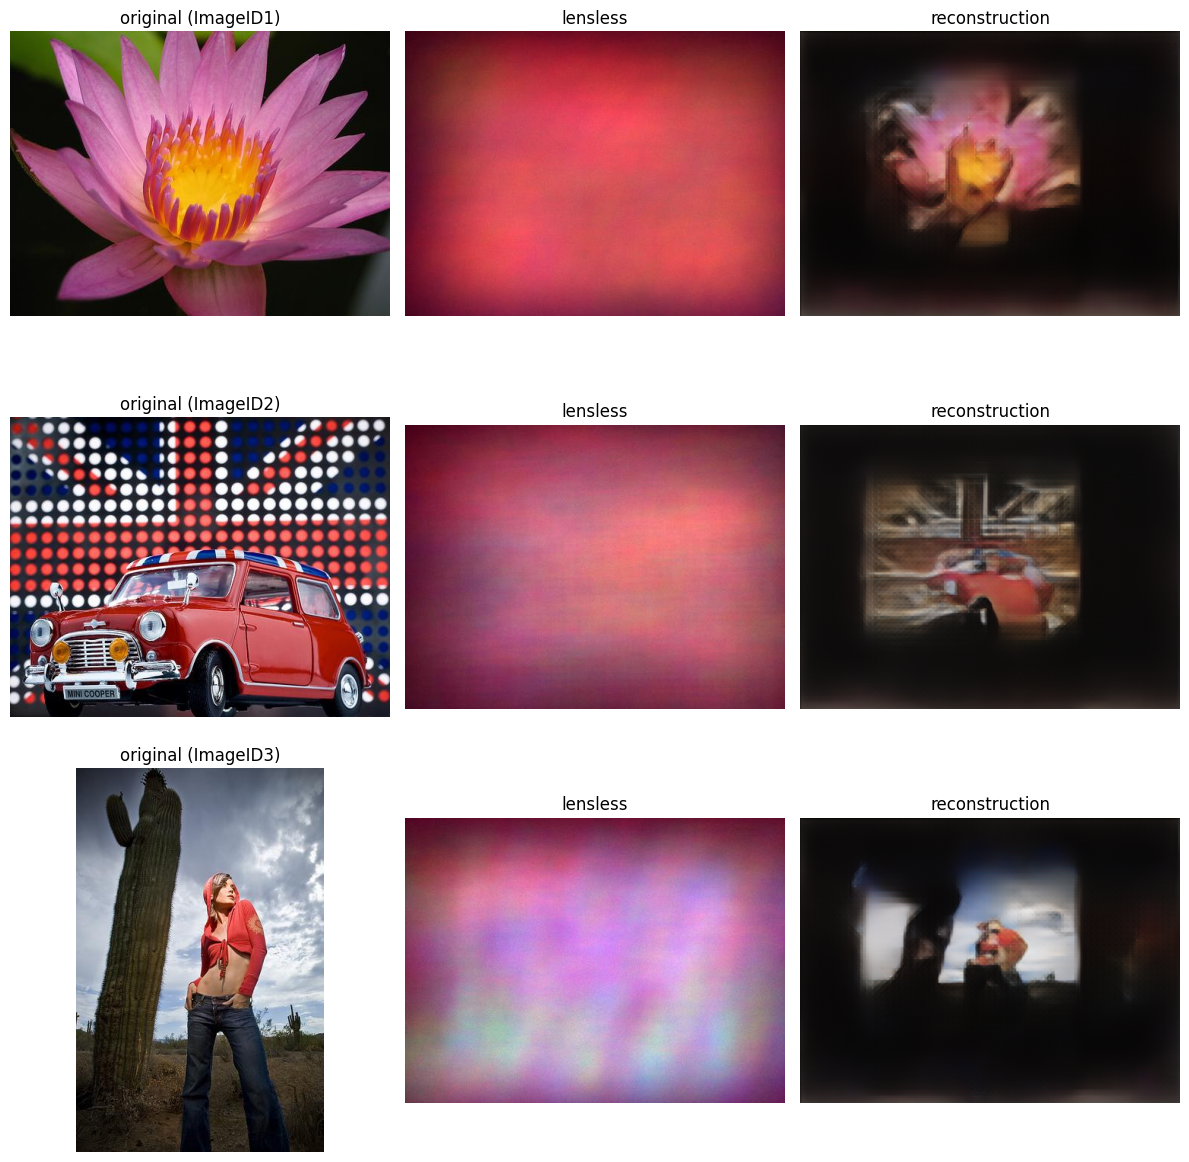

In [7]:
import os, glob, numpy as np
import matplotlib.pyplot as plt
from PIL import Image

def stretch(a):
    a = a.astype(np.float32)
    a -= a.min()
    return a / (a.max() + 1e-8)

recon_ids = [os.path.splitext(os.path.basename(p))[0] for p in sorted(glob.glob(f"{SAVE_DIR}/*.png"))]

n_samples = 4 # Если хотите посмотреть больше примеров, введите свое число
n = min(4, len(recon_ids))

has_lensed = os.path.isdir(f"{DATA_DIR}/lensed")
cols = 3 if has_lensed else 2

fig, axes = plt.subplots(n, cols, figsize=(4 * cols, 4 * n))
axes = np.atleast_2d(axes)

for row, img_id in enumerate(recon_ids[:n]):
    col = 0
    if has_lensed:
        gt = glob.glob(f"{DATA_DIR}/lensed/{img_id}.*")
        if gt:
            axes[row, col].imshow(np.array(Image.open(gt[0]).convert("RGB")))
            axes[row, col].set_title(f"original ({img_id})")
        col += 1

    lensless = glob.glob(f"{DATA_DIR}/lensless/{img_id}.*")

    axes[row, col].imshow(stretch(np.array(Image.open(lensless[0]).convert("RGB"))))
    axes[row, col].set_title("lensless")
    col += 1

    axes[row, col].imshow(np.array(Image.open(f"{SAVE_DIR}/{img_id}.png")))
    axes[row, col].set_title("reconstruction")

    for k in range(cols):
        axes[row, k].axis("off")

plt.tight_layout()
plt.show()

## 5. Подсчёт метрик (только если есть оригинальные изображения)

Скрипт сопоставляет реконструкции с оригинальными изображениями из папки `lensed/` по ID и выводит 4 метрики на ROI.

In [8]:
!/content/lensless_env/bin/python calculate_metrics.py \
    ~writer \
    +gt_dir="{os.path.join(DATA_DIR, "lensed")}" \
    +recon_dir={SAVE_DIR}

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


Metrics on 3 image pairs:
PSNR: 15.64141050974528
LPIPS: 0.5555715362230936
MSE: 0.03269056665400664
SSIM: 0.3801170339186986


Если вы хотите посчитать метрике на тестовой выборке датасета Mirflickr, то запустите этот скрипт(но он будет работать дольше в силу большого размера датасета).

In [9]:
CONFIG_NAME = f"modular" if "admm" not in label else "admm_unrolled"

In [10]:
!/content/lensless_env/bin/python calculate_metrics.py \
  --config-name={CONFIG_NAME} \
  model={MODEL_CONFIG} \
  ~writer \
  +from_pretrained={CHECKPOINT_PATH}


[2026-06-18 12:06:21,261][huggingface_hub.utils._http][WARNING] - Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.













[2026-06-18 12:10:09,100][eval][INFO] - ModularReconstruction(
  (pre): DRUNet(
    (input_conv): Conv2d(3, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (down_block1): DownBlock(
      (res_blocks): Sequential(
        (0): ResBlock(
          (conv1): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (act): ReLU()
          (conv2): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        )
        (1): ResBlock(
          (conv1): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (act): ReLU()
          (conv2): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        )
        (2): ResBlock(
          (conv1): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1,